# VRP Analysis
Analyse the variance risk premium (VRP) across tickers using precomputed signals from `vrp_signals_PRECOMPUTED/` (2020–2024). Computes forward-looking VRP (implied variance minus future realised variance), runs statistical significance tests (naive t-test, HAC-robust, non-overlapping), and visualises cross-sectional patterns between VRP and option liquidity.

## Setup and Imports
Load utility functions from `analysis_utils` for VRP computation, signal aggregation, and visualisation. All file paths are relative to the notebook's working directory.

In [35]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pathlib import Path
BASE_DIR = Path.cwd()
file_path = BASE_DIR / "vrp_signals_PRECOMPUTED"

from analysis_utils import (
    load_span, plot_vrp, summarise_vrp_ticker, compute_composite_signal
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Precomputed Signals
Load monthly signal files from `vrp_signals_PRECOMPUTED/` for the 2020–2024 period and compute composite signals. These signals were originally generated by `vrp_signal.py` over the full options dataset.

In [36]:
# Load all monthly signal files and compute composite signals
start_month = "2020-01"
end_month   = "2024-12"

all_signals = load_span(file_path, start_month, end_month, prefix="signals")
compute_composite_signal(all_signals)

print("Number of tickers: ", len(all_signals["ticker"].unique()))
print("Dataframe Size: ", all_signals.shape)

all_signals.head()

Number of tickers:  224
Dataframe Size:  (228010, 20)


,ticker,trade_date,rvol30_yz,rvol30_cc,ivar30,dte0,atm_iv0,atm_iv30,atm_iv45,atm_iv60,avg_underlying_volume,daily_option_volume,market_iv30,iv30_rv30,fwd_var_30_60,fwd_iv_30_60,fwd_factor_30_60,ts_slope_30,ts_slope_45,ts_slope_60
0,SPY,2020-01-02,0.080713,0.070719,0.013251,1.0,0.090272,0.103642,0.113166,0.117472,66198592.0,2209546,0.115111,1.284082,0.016858,0.129837,-0.201753,0.000461,0.000520,0.000461
1,AAPL,2020-01-02,0.181758,0.167693,0.099107,1.0,0.278055,0.307495,0.287475,0.275248,120199576.0,996937,0.314813,1.691782,0.056970,0.238684,0.288293,0.001015,0.000214,-0.000048
2,QQQ,2020-01-02,0.151918,0.092578,0.024892,1.0,0.125808,0.134241,0.143461,0.151857,21485188.0,616398,0.157771,0.883643,0.028100,0.167632,-0.199191,0.000291,0.000401,0.000442
3,SPX,2020-01-02,0.071674,0.070845,0.015631,1.0,0.088749,0.101983,0.109302,0.111174,0.0,602856,0.125024,1.422873,0.014319,0.119660,-0.147730,0.000456,0.000467,0.000380
4,TSLA,2020-01-02,0.309617,0.328577,0.293231,1.0,0.753745,0.535368,0.517348,0.492128,150618416.0,339984,0.541508,1.729127,0.197762,0.444705,0.203872,-0.007530,-0.005373,-0.004434


## Compute VRP
Compute forward-looking realised variance by shifting the Yang-Zhang realised variance 21 trading days into the future. The variance risk premium is then defined as VRP = implied variance (IV) − forward realised variance (RV).

In [37]:
# Keep only the columns needed for VRP computation to save memory
vrp_df = all_signals[["ticker", "trade_date", "rvol30_yz", "rvol30_cc", "ivar30", "atm_iv30", "market_iv30"]].copy()

# Realised variance from Yang-Zhang vol
vrp_df["rvar30"] = vrp_df["rvol30_yz"] ** 2

# Forward-looking realised variance: shift by 21 trading days
vrp_df = vrp_df.sort_values(["ticker", "trade_date"]).reset_index(drop=True)
vrp_df["forward_rvar30"] = vrp_df.groupby("ticker")["rvar30"].shift(-21)
vrp_df["forward_rvol30"] = np.sqrt(vrp_df["forward_rvar30"])

# VRP = implied variance - forward realised variance
vrp_df["vrp"] = vrp_df["ivar30"] - vrp_df["forward_rvar30"]

latex = vrp_df.head(5).drop(columns=["atm_iv30"]).to_latex(index=False, float_format="%.4f")
# print(latex)

vrp_df.head()

,ticker,trade_date,rvol30_yz,rvol30_cc,ivar30,atm_iv30,market_iv30,rvar30,forward_rvar30,forward_rvol30,vrp
0,AA,2021-01-04,0.558849,0.499873,0.495044,0.689756,0.703593,0.312313,0.515330,0.717865,-0.020286
1,AA,2021-01-05,0.575044,0.498844,0.520263,0.681456,0.721292,0.330676,0.527883,0.726555,-0.007620
2,AA,2021-01-06,0.560895,0.480059,0.551711,0.667948,0.742773,0.314603,0.505421,0.710930,0.046290
3,AA,2021-01-07,0.577180,0.475910,0.519946,0.656431,0.721073,0.333137,0.499903,0.707039,0.020042
4,AA,2021-01-08,0.579715,0.477421,0.512919,0.655980,0.716184,0.336070,0.500328,0.707339,0.012591


## Filter Top Tickers
Load yearly ticker universes, intersect to find tickers available across all years, and rank by average option volume.

The year range here doesn't matter much since we're only using it to filter tickers. This is the same across demo and actual backtest.

In [38]:
from functools import reduce

# load tickers list
start_year = 2021
end_year = 2025
path = BASE_DIR / "data" / "ticker_universe.xlsx"
tickers_by_year = []
for year in range(start_year, end_year + 1):
    df = pd.read_excel(path, sheet_name=f"{year}")
    tickers_by_year.append(df)

# Rename volume column by year before merging
for i, df in enumerate(tickers_by_year):
    year = start_year + i
    tickers_by_year[i] = df.rename(columns={"avg_option_volume": str(year)})

# Inner join all on 'ticker'
merged = reduce(lambda left, right: pd.merge(left, right, on="ticker"), tickers_by_year)

# Compute average across year columns
year_cols = [str(y) for y in range(start_year, end_year + 1)]
merged["avg_volume"] = merged[year_cols].mean(axis=1)

result = merged.sort_values("avg_volume", ascending=False).reset_index(drop=True)

top_30_tickers = result.head(35)["ticker"].tolist() # room for some tickers to be dropped later if they dont have volume data

result

,ticker,2021,2022,2023,2024,2025,avg_volume
0,SPY,4069377.36,6743765.62,7438223.20,7139136.50,8529380.24,6783976.584
1,QQQ,1287691.66,2367971.90,3116482.70,3553337.84,4058881.54,2876873.128
2,SPX,1150749.78,2293434.98,2547126.10,2773254.02,3443807.64,2441674.504
3,TSLA,1267368.72,1573972.70,2036563.46,2090131.50,2427774.04,1879162.084
4,NVDA,360170.10,517454.12,946533.80,2674951.02,3017587.88,1503339.384
...,...,...,...,...,...,...,...
4092,PSCM,0.00,0.02,0.00,0.00,0.10,0.024
4093,IFV,0.00,0.00,0.02,0.00,0.06,0.016
4094,LDEM,0.02,0.02,0.00,0.00,0.00,0.008
4095,HYBB,0.00,0.00,0.02,0.00,0.00,0.004


## Summarise VRP
Compute per-ticker VRP statistics (mean, median, standard deviation) and run one-sided significance tests (naive t-test, HAC-robust, non-overlapping samples) to determine whether VRP is statistically positive. Results are exported to `tabs_and_figs/vrp_summary.xlsx` and filtered to the top 30 tickers by average option volume.

In [39]:
# Summarise VRP per ticker with statistical significance tests
vrp_grouped = vrp_df.groupby("ticker")
rows = []
for ticker, group in vrp_grouped:
    vrp_df_ticker = group.sort_values("trade_date").reset_index(drop=True)
    vol_row = result[result["ticker"] == ticker]["avg_volume"].values
    if len(vol_row) == 1:
        ticker_volume = vol_row[0]
    else:
        continue  # skip tickers without volume data
    vrp_dict = summarise_vrp_ticker(vrp_df_ticker, ticker, ticker_volume)
    rows.append(vrp_dict)

summary_df = pd.DataFrame(rows)
summary_df.to_excel(BASE_DIR / "tabs_and_figs" / "vrp_summary.xlsx", index=False)

# Filter to top-30 tickers by option volume
top_30_df = (
    summary_df[summary_df["ticker"].isin(top_30_tickers)]
    .sort_values("average_option_volume", ascending=False)
    .reset_index(drop=True)
    .copy()
)

latex = top_30_df.drop(columns=["t_naive", "p_naive_one_sided", "t_nonoverlap", "p_nonoverlap_one_sided"]).to_latex(index=False, float_format="%.4f")
print(latex)

# Count statistically significant tickers at 5% level
c = (top_30_df["p_naive_one_sided"] < 0.05).sum()
print(f"Number of significant tickers (p_naive_one_sided < 0.05): {c}")
c = (top_30_df["p_hac_one_sided"] < 0.05).sum()
print(f"Number of significant tickers (p_hac_one_sided < 0.05): {c}")
c = (top_30_df["p_nonoverlap_one_sided"] < 0.05).sum()
print(f"Number of significant tickers (p_nonoverlap_one_sided < 0.05): {c}")

top_30_df

\begin{tabular}{lrrrrrrrr}
\toprule
ticker & mean_ivar & mean_rvar & mean_vrp & var_vrp & skew_vrp & t_hac & p_hac_one_sided & average_option_volume \\
\midrule
SPY & 0.0514 & 0.0465 & 0.0049 & 0.0087 & -6.6229 & 0.4900 & 0.3132 & 6783977.0000 \\
QQQ & 0.0734 & 0.0638 & 0.0096 & 0.0082 & -5.9264 & 1.0000 & 0.1595 & 2876873.0000 \\
SPX & 0.0518 & 0.0331 & 0.0186 & 0.0032 & -3.3309 & 3.2900 & 0.0005 & 2441675.0000 \\
TSLA & 0.5058 & 0.4656 & 0.0402 & 0.2547 & 2.1965 & 0.9000 & 0.1836 & 1879162.0000 \\
NVDA & 0.2895 & 0.2833 & 0.0062 & 0.0507 & -2.9989 & 0.2600 & 0.3970 & 1503339.0000 \\
AAPL & 0.1165 & 0.1034 & 0.0131 & 0.0156 & -4.4032 & 1.0100 & 0.1559 & 1090221.0000 \\
IWM & 0.0867 & 0.0801 & 0.0066 & 0.0111 & -6.4115 & 0.5700 & 0.2830 & 966772.0000 \\
VIX & 1.1689 & 1.8397 & -0.6708 & 3.0715 & -3.7968 & -3.5200 & 0.9998 & 621910.0000 \\
AMD & 0.2986 & 0.2688 & 0.0299 & 0.0392 & -1.1320 & 1.5200 & 0.0638 & 598661.0000 \\
AMZN & 0.1481 & 0.1385 & 0.0097 & 0.0095 & -2.2133 & 0.9500 & 0.

,ticker,mean_ivar,mean_rvar,mean_vrp,var_vrp,skew_vrp,t_naive,p_naive_one_sided,t_hac,p_hac_one_sided,t_nonoverlap,p_nonoverlap_one_sided,average_option_volume
0,SPY,0.0514,0.0465,0.0049,0.008700,-6.6229,1.83,0.0336,0.49,0.3132,0.23,0.4079,6783977.0
1,QQQ,0.0734,0.0638,0.0096,0.008200,-5.9264,3.73,0.0001,1.00,0.1595,0.56,0.2889,2876873.0
2,SPX,0.0518,0.0331,0.0186,0.003200,-3.3309,11.55,0.0000,3.29,0.0005,2.09,0.0204,2441675.0
3,TSLA,0.5058,0.4656,0.0402,0.254700,2.1965,2.80,0.0026,0.90,0.1836,0.47,0.3206,1879162.0
4,NVDA,0.2895,0.2833,0.0062,0.050700,-2.9989,0.97,0.1665,0.26,0.3970,-0.37,0.6419,1503339.0
5,AAPL,0.1165,0.1034,0.0131,0.015600,-4.4032,3.68,0.0001,1.01,0.1559,0.61,0.2722,1090221.0
6,IWM,0.0867,0.0801,0.0066,0.011100,-6.4115,2.20,0.0139,0.57,0.2830,0.30,0.3840,966772.0
7,VIX,1.1689,1.8397,-0.6708,3.071500,-3.7968,-13.46,1.0000,-3.52,0.9998,-2.85,0.9970,621910.0
8,AMD,0.2986,0.2688,0.0299,0.039200,-1.1320,5.31,0.0000,1.52,0.0638,0.98,0.1657,598661.0
9,AMZN,0.1481,0.1385,0.0097,0.009500,-2.2133,3.48,0.0003,0.95,0.1720,0.30,0.3814,596959.0


## Box Plot and Scatter Plot of VRP vs. Volume
Visualise the distribution of mean VRP across tickers and its relationship with average option volume.

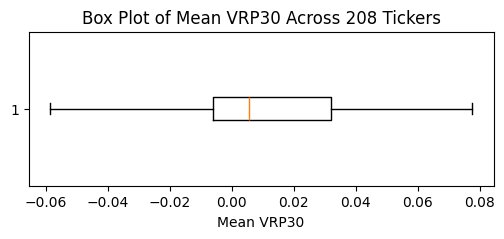

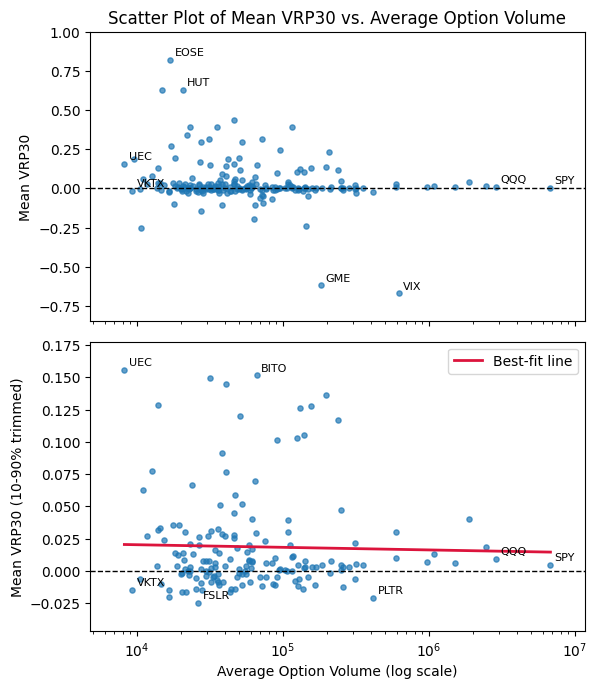

In [40]:
# --- Box plot of mean VRP30 ---
plt.figure(figsize=(6, 2))
plt.boxplot(summary_df["mean_vrp"], vert=False, showfliers=False)
plt.title(f"Box Plot of Mean VRP30 Across {len(summary_df)} Tickers")
plt.xlabel("Mean VRP30")
plt.savefig(BASE_DIR / "tabs_and_figs" / "ch4_boxplot_mean_vrp30.png", bbox_inches="tight")
plt.show()

# --- Scatter: mean VRP vs average option volume (full + trimmed) ---
x = summary_df["average_option_volume"]
y = summary_df["mean_vrp"]
t = summary_df["ticker"]

# Trim top/bottom 10% VRP for the lower panel
q_low, q_high = y.quantile([0.1, 0.9])
mask_trim = y.between(q_low, q_high)
x_trim = x[mask_trim]
y_trim = y[mask_trim]
t_trim = t[mask_trim]

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

# Top: full-range scatter
ax_top.scatter(x, y, s=14, alpha=0.7)
ax_top.set_xscale("log")
ax_top.axhline(0, color="black", linewidth=1, linestyle="--")
ax_top.set_title("Scatter Plot of Mean VRP30 vs. Average Option Volume")
ax_top.set_ylabel("Mean VRP30")
ax_top.margins(x=0.08, y=0.12)

# Label extremes: top/bottom 2 by VRP and by liquidity
top_vrp_idx = y.nlargest(2).index
bot_vrp_idx = y.nsmallest(2).index
top_liq_idx = x.nlargest(2).index
bot_liq_idx = x.nsmallest(2).index

label_idx = pd.Index(top_vrp_idx).union(pd.Index(bot_vrp_idx))
label_idx = label_idx.union(pd.Index(top_liq_idx))
label_idx = label_idx.union(pd.Index(bot_liq_idx))

for i in label_idx:
    ax_top.annotate(
        t.loc[i],
        (x.loc[i], y.loc[i]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
        clip_on=False,
    )

# Bottom: trimmed scatter (drop top/bottom 10% VRP)
ax_bottom.scatter(x_trim, y_trim, s=14, alpha=0.7)
ax_bottom.set_xscale("log")
ax_bottom.axhline(0, color="black", linewidth=1, linestyle="--")
ax_bottom.margins(x=0.08, y=0.12)

# Label extremes in trimmed panel
top_vrp_idx_trim = y_trim.nlargest(2).index
bot_vrp_idx_trim = y_trim.nsmallest(2).index
top_liq_idx_trim = x_trim.nlargest(2).index
bot_liq_idx_trim = x_trim.nsmallest(2).index

label_idx_trim = pd.Index(top_vrp_idx_trim).union(pd.Index(bot_vrp_idx_trim))
label_idx_trim = label_idx_trim.union(pd.Index(top_liq_idx_trim))
label_idx_trim = label_idx_trim.union(pd.Index(bot_liq_idx_trim))

for i in label_idx_trim:
    ax_bottom.annotate(
        t_trim.loc[i],
        (x_trim.loc[i], y_trim.loc[i]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
        clip_on=False,
    )

# Best-fit line on trimmed data (log10 x-axis)
x_fit = x_trim.to_numpy(dtype=float)
y_fit = y_trim.to_numpy(dtype=float)
if len(x_fit) >= 2 and np.all(x_fit > 0):
    m, b = np.polyfit(np.log10(x_fit), y_fit, 1)
    x_line = np.linspace(x_fit.min(), x_fit.max(), 200)
    y_line = m * np.log10(x_line) + b
    ax_bottom.plot(x_line, y_line, color="crimson", linewidth=2, label="Best-fit line")
    ax_bottom.legend()

ax_bottom.set_xlabel("Average Option Volume (log scale)")
ax_bottom.set_ylabel("Mean VRP30 (10-90% trimmed)")

plt.tight_layout(pad=1.1)
plt.savefig(BASE_DIR / "tabs_and_figs" / "ch4_vrp_vs_volume.png", bbox_inches="tight")
plt.show()

## Interactive Scatter
Same VRP vs. volume scatter as above, but with hover tooltips via Plotly.

In [41]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Prepare data for interactive scatter
scatter_df = summary_df[["ticker", "average_option_volume", "mean_vrp"]].dropna().copy()

# Trim top/bottom 5% VRP for lower panel
q_low, q_high = scatter_df["mean_vrp"].quantile([0.05, 0.95])
scatter_trim = scatter_df[scatter_df["mean_vrp"].between(q_low, q_high)].copy()

fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=(
        "Scatter Plot of Mean VRP30 vs. Average Option Volume",
        "Scatter Plot of Mean VRP30 vs. Average Option Volume (5-95% VRP Trimmed)",
    ),
)

hover_tmpl = (
    "Ticker: %{customdata[0]}<br>"
    "Mean VRP30: %{y:.6f}<br>"
    "Average Option Volume: %{x:,.0f}<extra></extra>"
)

# Top: full-range scatter
fig.add_trace(
    go.Scattergl(
        x=scatter_df["average_option_volume"],
        y=scatter_df["mean_vrp"],
        mode="markers",
        marker=dict(size=6, opacity=0.7),
        customdata=np.stack([scatter_df["ticker"]], axis=1),
        hovertemplate=hover_tmpl,
        name="Full range",
    ),
    row=1, col=1,
)

# Bottom: VRP-trimmed scatter
fig.add_trace(
    go.Scattergl(
        x=scatter_trim["average_option_volume"],
        y=scatter_trim["mean_vrp"],
        mode="markers",
        marker=dict(size=6, opacity=0.7),
        customdata=np.stack([scatter_trim["ticker"]], axis=1),
        hovertemplate=hover_tmpl,
        name="Trimmed",
        showlegend=False,
    ),
    row=2, col=1,
)

# Best-fit line on trimmed data (log10 x-axis)
x_fit = scatter_trim["average_option_volume"].to_numpy(dtype=float)
y_fit = scatter_trim["mean_vrp"].to_numpy(dtype=float)
if len(x_fit) >= 2 and np.all(x_fit > 0):
    m, b = np.polyfit(np.log10(x_fit), y_fit, 1)
    x_line = np.linspace(x_fit.min(), x_fit.max(), 200)
    y_line = m * np.log10(x_line) + b
    fig.add_trace(
        go.Scatter(
            x=x_line, y=y_line,
            mode="lines",
            line=dict(color="crimson", width=2),
            name="Best-fit line",
            hovertemplate="Best-fit line<extra></extra>",
        ),
        row=2, col=1,
    )

fig.update_xaxes(type="log", title_text="Average Option Volume (log scale)", row=2, col=1)
fig.update_xaxes(type="log", row=1, col=1)
fig.update_yaxes(title_text="Mean VRP30", row=1, col=1)
fig.update_yaxes(title_text="Mean VRP30 (5-95% trimmed)", row=2, col=1)

fig.update_layout(
    height=750, width=700,
    template="plotly_white",
    margin=dict(l=60, r=30, t=80, b=60),
)

fig.show()

## VRP Time Series Grid
Plot implied variance vs forward realised variance and VRP for selected tickers.

Note: to analyse volume over the past 5 years, restrict VRP data accordingly and recompute averages.

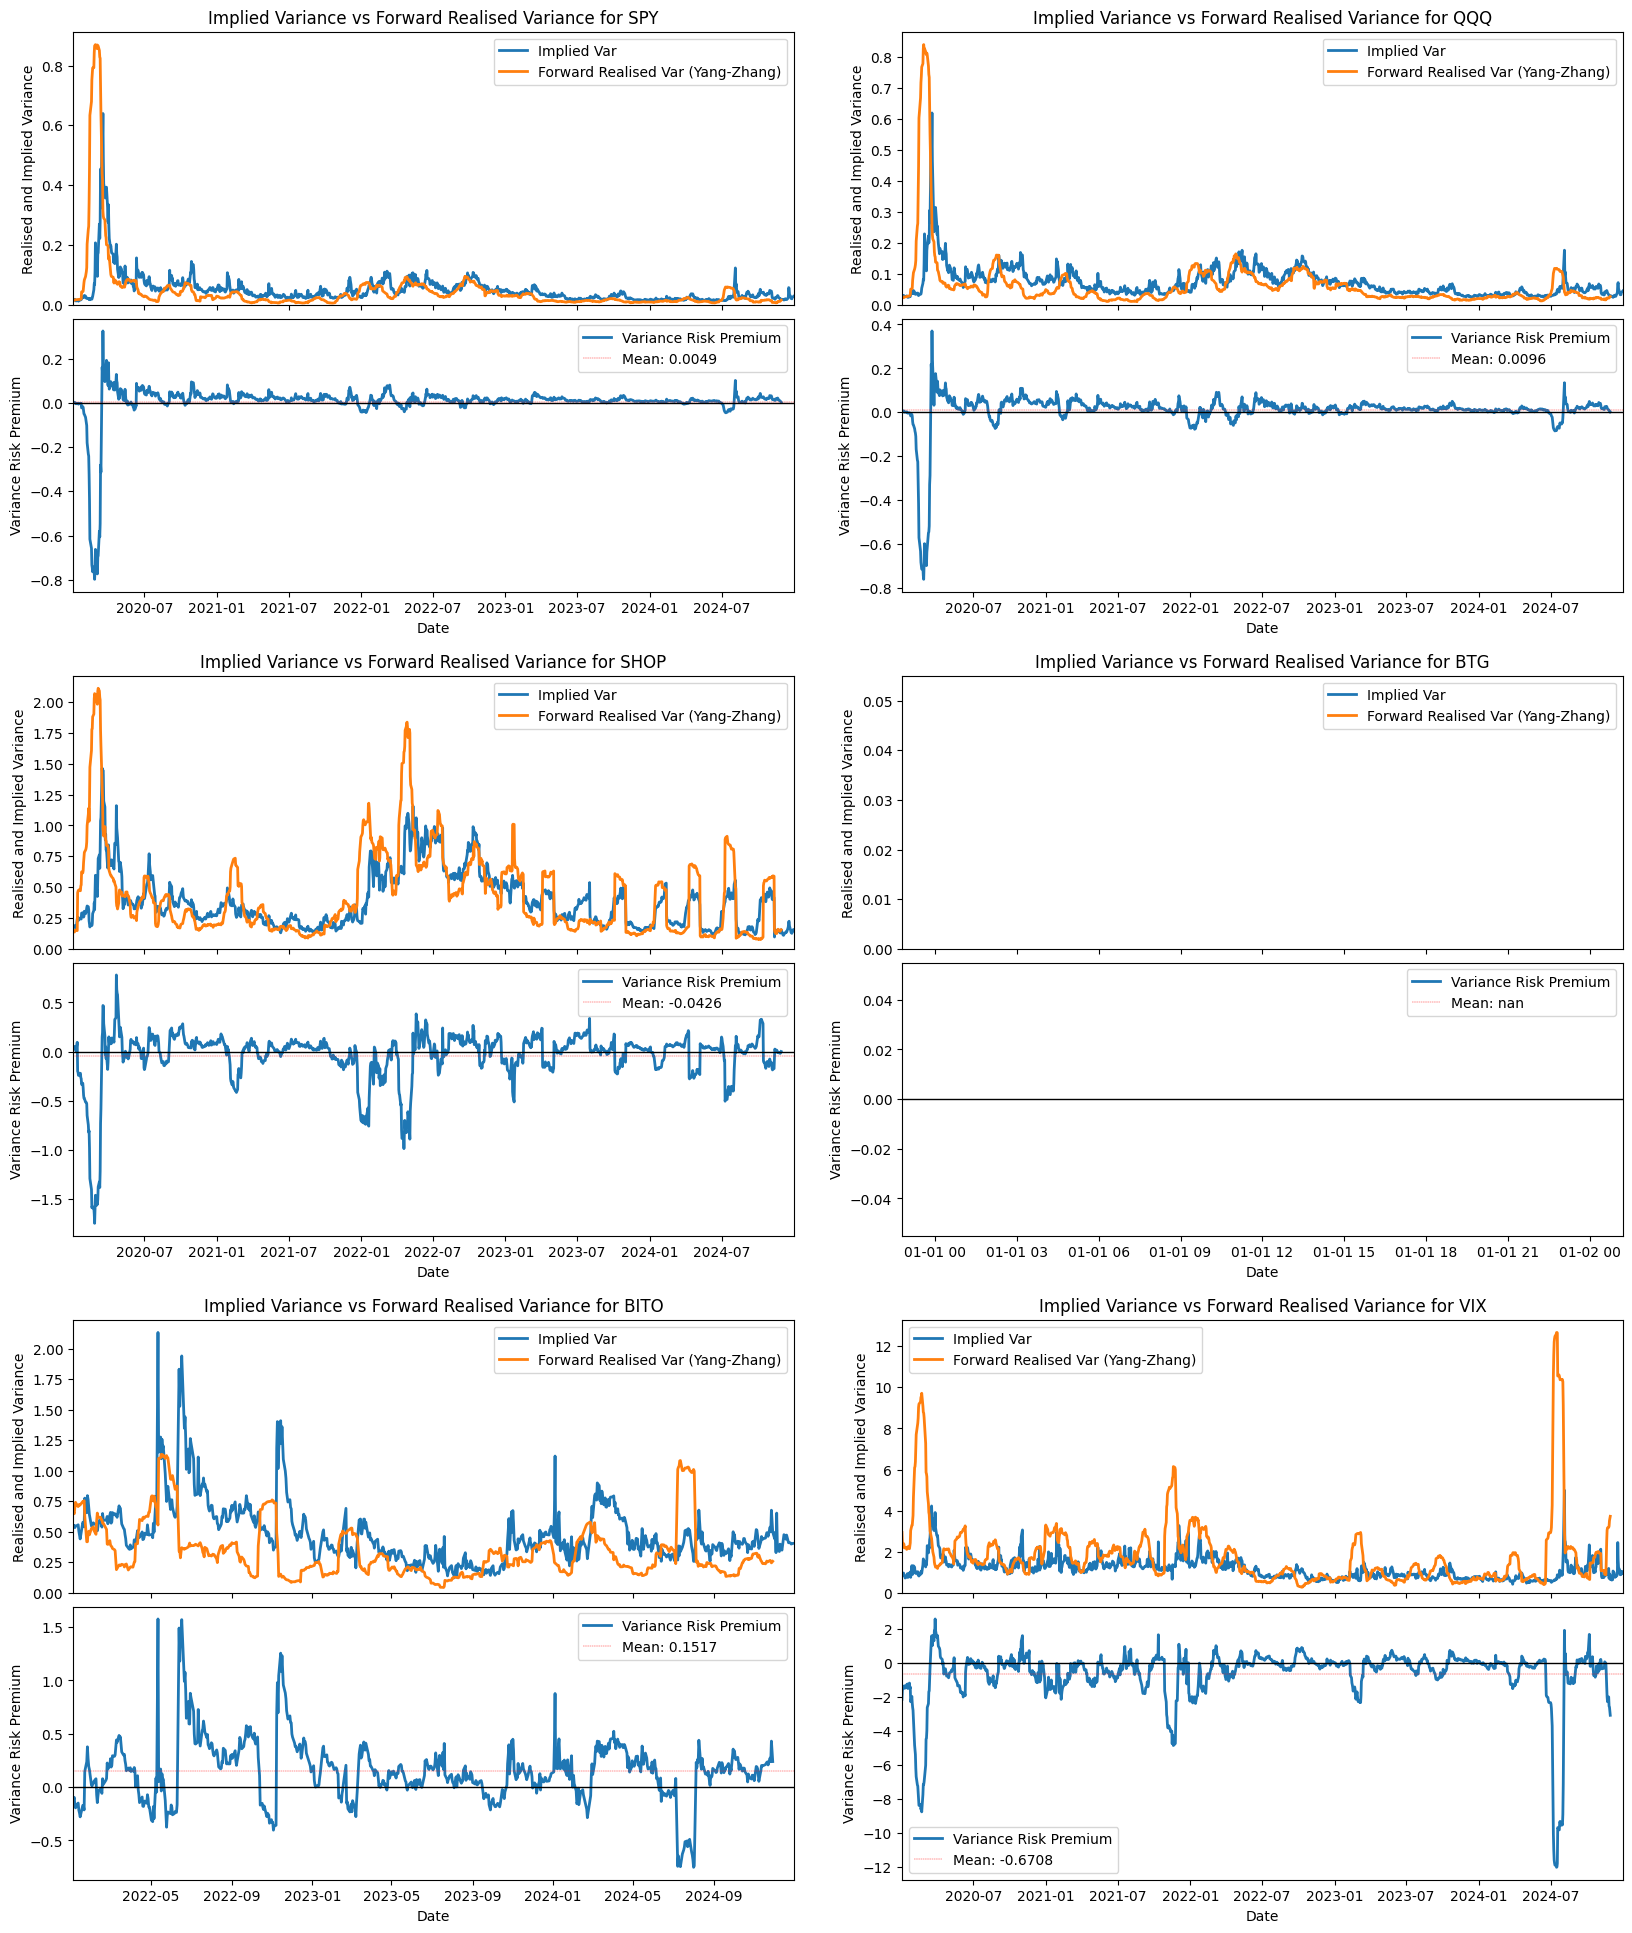

In [42]:
# Grid of VRP charts for selected tickers
tickers = ["SPY", "QQQ", "SHOP", "BTG", "BITO", "VIX"]
outer_rows, outer_cols = 3, 2

fig = plt.figure(figsize=(20, 24))
outer_grid = fig.add_gridspec(outer_rows, outer_cols, hspace=0.15, wspace=0.15)

for slot, ticker in enumerate(tickers):
    row, col = divmod(slot, outer_cols)
    inner_grid = outer_grid[row, col].subgridspec(2, 1, hspace=0.05)

    ax_top = fig.add_subplot(inner_grid[0, 0])
    ax_bottom = fig.add_subplot(inner_grid[1, 0], sharex=ax_top)

    vrp_df_ticker = (
        vrp_df[vrp_df["ticker"] == ticker]
        .sort_values("trade_date")
        .reset_index(drop=True)
    )

    plot_vrp(
        vrp_df_ticker,
        ticker=ticker,
        axes=(ax_top, ax_bottom),
        show=False,
        save=False,
    )

    ax_top.tick_params(axis="x", labelbottom=False)

# Hide unused subplots
for slot in range(len(tickers), outer_rows * outer_cols):
    row, col = divmod(slot, outer_cols)
    empty_ax = fig.add_subplot(outer_grid[row, col])
    empty_ax.axis("off")

fig.savefig(BASE_DIR / "tabs_and_figs" / "ch4_vrp_grid.png", bbox_inches="tight")
plt.show()

## Investigation and Debug
Ad-hoc inspection of individual tickers and data quality checks. These cells are not part of the main analysis pipeline.

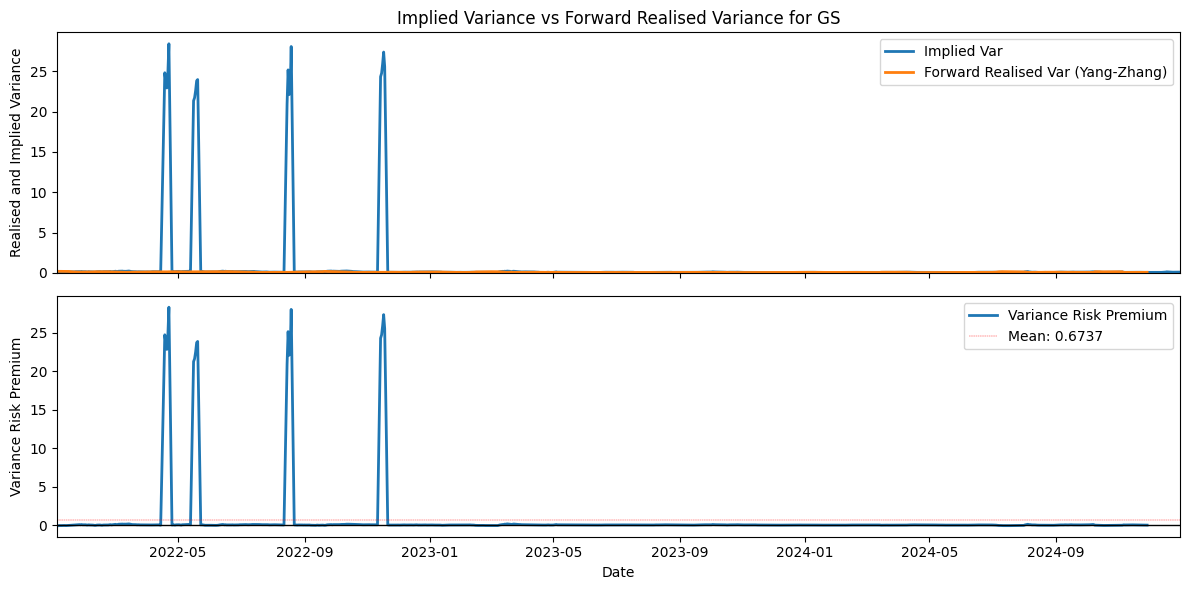

(<Figure size 1200x600 with 2 Axes>,
 (<Axes: title={'center': 'Implied Variance vs Forward Realised Variance for GS'}, ylabel='Realised and Implied Variance'>,
  <Axes: xlabel='Date', ylabel='Variance Risk Premium'>))

In [43]:
# Single-ticker VRP chart: GS from 2022 onward
vrp_df_gs = (
    vrp_df[
        (vrp_df["ticker"] == "GS")
        & (pd.to_datetime(vrp_df["trade_date"]) >= pd.Timestamp("2022-01-01"))
    ]
    .sort_values("trade_date")
    .reset_index(drop=True)
)

plot_vrp(vrp_df_gs, ticker="GS", path=BASE_DIR / "tabs_and_figs")

In [44]:
# Inspect SPX VRP around a specific date range
vrp_df_spx = vrp_df[vrp_df["ticker"] == "SPX"].sort_values("trade_date").reset_index(drop=True)

start_date = "2013-12-01"
end_date = "2014-01-20"
vrp_df_spx = vrp_df_spx[(vrp_df_spx["trade_date"] >= start_date) & (vrp_df_spx["trade_date"] <= end_date)].reset_index(drop=True)
vrp_df_spx

,ticker,trade_date,rvol30_yz,rvol30_cc,ivar30,atm_iv30,market_iv30,rvar30,forward_rvar30,forward_rvol30,vrp


In [45]:
# Check NaN counts in underlying data (expect none after the initial warm-up period)
underlying_df = pd.read_parquet(BASE_DIR / "data" / "300_underlyings_processed.parquet")

print(underlying_df.isna().sum())
print()
print(underlying_df[underlying_df["trade_date"] > "2011-03-01"].isna().sum())

ticker              0
trade_date          0
close               0
high                0
low                 0
open                0
volume              0
avg_volume_30    5180
rvar30_yz        5439
rvar30_cc        5439
rvol30_yz        5439
rvol30_cc        5439
dtype: int64

ticker              0
trade_date          0
close               0
high                0
low                 0
open                0
volume              0
avg_volume_30    2540
rvar30_yz        2667
rvar30_cc        2667
rvol30_yz        2667
rvol30_cc        2667
dtype: int64
